# 08 - Global Results Comparison (Two Datasets)

Objectif:
- Agreger les resultats d'attaques et defenses depuis les notebooks executes.
- Comparer les performances MIA entre les deux datasets.

Datasets couverts:
- OASIS (pipelines: transformer, standart, vulnerable)
- Alzheimer HF (pipeline transformer_hf ; defenses inclues si notebooks disponibles)

In [1]:
import io
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 220)

ROOT = Path('.')

SOURCES = [
    # Dataset 1: OASIS
    {'dataset': 'oasis', 'pipeline': 'transformer', 'stage': 'baseline', 'path': ROOT/'transformer_pipeline'/'02_transformer_baseline_and_attacks.ipynb'},
    {'dataset': 'oasis', 'pipeline': 'transformer', 'stage': 'defense1', 'path': ROOT/'transformer_pipeline'/'03_transformer_with_defense1_regularization.ipynb'},
    {'dataset': 'oasis', 'pipeline': 'transformer', 'stage': 'defense2', 'path': ROOT/'transformer_pipeline'/'04_transformer_with_defense2_output_limiting.ipynb'},
    {'dataset': 'oasis', 'pipeline': 'transformer', 'stage': 'defense3', 'path': ROOT/'transformer_pipeline'/'05_transformer_with_defense3_differential_privacy.ipynb'},
    {'dataset': 'oasis', 'pipeline': 'transformer', 'stage': 'defense4', 'path': ROOT/'transformer_pipeline'/'06_transformer_with_defense4_knowledge_distillation.ipynb'},

    {'dataset': 'oasis', 'pipeline': 'standart', 'stage': 'baseline', 'path': ROOT/'standart'/'02_standart_baseline_and_attacks.ipynb'},
    {'dataset': 'oasis', 'pipeline': 'standart', 'stage': 'defense1', 'path': ROOT/'standart'/'03_standart_with_defense1_regularization.ipynb'},
    {'dataset': 'oasis', 'pipeline': 'standart', 'stage': 'defense2', 'path': ROOT/'standart'/'04_standart_with_defense2_output_limiting.ipynb'},
    {'dataset': 'oasis', 'pipeline': 'standart', 'stage': 'defense3', 'path': ROOT/'standart'/'05_standart_with_defense3_differential_privacy.ipynb'},
    {'dataset': 'oasis', 'pipeline': 'standart', 'stage': 'defense4', 'path': ROOT/'standart'/'06_standart_with_defense4_knowledge_distillation.ipynb'},

    {'dataset': 'oasis', 'pipeline': 'vulnerable', 'stage': 'baseline', 'path': ROOT/'vulnerable'/'02_vulnerable_baseline_and_attacks.ipynb'},
    {'dataset': 'oasis', 'pipeline': 'vulnerable', 'stage': 'defense1', 'path': ROOT/'vulnerable'/'03_vulnerable_with_defense1_regularization.ipynb'},
    {'dataset': 'oasis', 'pipeline': 'vulnerable', 'stage': 'defense2', 'path': ROOT/'vulnerable'/'04_vulnerable_with_defense2_output_limiting.ipynb'},
    {'dataset': 'oasis', 'pipeline': 'vulnerable', 'stage': 'defense3', 'path': ROOT/'vulnerable'/'05_vulnerable_with_defense3_differential_privacy.ipynb'},
    {'dataset': 'oasis', 'pipeline': 'vulnerable', 'stage': 'defense4', 'path': ROOT/'vulnerable'/'06_vulnerable_with_defense4_knowledge_distillation.ipynb'},

    # Dataset 2: Alzheimer HF
    {'dataset': 'alzheimer_hf', 'pipeline': 'transformer_hf', 'stage': 'baseline', 'path': ROOT/'transformer_pipeline_alzheimer_hf'/'02_transformer_baseline_and_attacks_alzheimer_hf.ipynb'},
]

In [2]:
def read_notebook(path: Path):
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding='utf-8-sig'))

def extract_html_tables(nb):
    tables = []
    if nb is None:
        return tables
    for cell in nb.get('cells', []):
        if cell.get('cell_type') != 'code':
            continue
        for out in cell.get('outputs', []):
            data = out.get('data', {}) if isinstance(out, dict) else {}
            html = data.get('text/html')
            if not html:
                continue
            html_s = ''.join(html) if isinstance(html, list) else str(html)
            try:
                dfs = pd.read_html(io.StringIO(html_s))
                tables.extend(dfs)
            except Exception:
                pass
    return tables

def normalize_cols(df):
    out = df.copy()
    out.columns = [str(c).strip().lower() for c in out.columns]
    return out

def pick_attack_auc_tables(tables):
    out = []
    for df in tables:
        dfn = normalize_cols(df)
        if 'attack' in dfn.columns and 'auc_mean' in dfn.columns:
            out.append(dfn)
    return out

def pick_compare_tables(tables):
    out = []
    for df in tables:
        dfn = normalize_cols(df)
        if 'attack' in dfn.columns and 'delta_auc' in dfn.columns:
            out.append(dfn)
    return out

In [3]:
rows_baseline = []
rows_defense = []
rows_status = []

for src in SOURCES:
    nb = read_notebook(src['path'])
    exists = nb is not None
    tables = extract_html_tables(nb) if exists else []
    attack_tables = pick_attack_auc_tables(tables)
    compare_tables = pick_compare_tables(tables)

    rows_status.append({
        'dataset': src['dataset'],
        'pipeline': src['pipeline'],
        'stage': src['stage'],
        'file_exists': exists,
        'n_attack_tables': len(attack_tables),
        'n_compare_tables': len(compare_tables),
    })

    if src['stage'] == 'baseline':
        # Convention in notebooks: first attack table = standard; second = robust
        std_auc = np.nan
        rob_auc = np.nan
        if len(attack_tables) >= 1:
            t = attack_tables[0]
            r = t[t['attack'].astype(str).str.lower() == 'shadow_meta']
            if not r.empty:
                std_auc = float(r.iloc[0]['auc_mean'])
        if len(attack_tables) >= 2:
            t = attack_tables[1]
            r = t[t['attack'].astype(str).str.lower() == 'shadow_meta']
            if not r.empty:
                rob_auc = float(r.iloc[0]['auc_mean'])

        rows_baseline.append({
            'dataset': src['dataset'],
            'pipeline': src['pipeline'],
            'standard_shadow_meta_auc': std_auc,
            'robust_shadow_meta_auc': rob_auc,
        })
    else:
        # Convention in defense notebooks: compare tables contain baseline/defense deltas.
        std_base = np.nan
        std_def = np.nan
        std_delta = np.nan
        rob_base = np.nan
        rob_def = np.nan
        rob_delta = np.nan

        if len(compare_tables) >= 1:
            t = compare_tables[0]
            r = t[t['attack'].astype(str).str.lower() == 'shadow_meta']
            if not r.empty:
                row = r.iloc[0]
                def_col = [c for c in t.columns if c.startswith('auc_mean_defense')]
                if def_col:
                    std_base = float(row['auc_mean_baseline'])
                    std_def = float(row[def_col[0]])
                    std_delta = float(row['delta_auc'])

        if len(compare_tables) >= 2:
            t = compare_tables[-1]
            r = t[t['attack'].astype(str).str.lower() == 'shadow_meta']
            if not r.empty:
                row = r.iloc[0]
                def_col = [c for c in t.columns if c.startswith('auc_mean_defense')]
                if def_col:
                    rob_base = float(row['auc_mean_baseline'])
                    rob_def = float(row[def_col[0]])
                    rob_delta = float(row['delta_auc'])

        rows_defense.append({
            'dataset': src['dataset'],
            'pipeline': src['pipeline'],
            'defense': src['stage'],
            'std_auc_baseline': std_base,
            'std_auc_defense': std_def,
            'std_delta_auc': std_delta,
            'rob_auc_baseline': rob_base,
            'rob_auc_defense': rob_def,
            'rob_delta_auc': rob_delta,
        })

status_df = pd.DataFrame(rows_status)
baseline_df = pd.DataFrame(rows_baseline)
defense_df = pd.DataFrame(rows_defense)

print('=== Notebook status (outputs found) ===')
display(status_df.sort_values(['dataset', 'pipeline', 'stage']).reset_index(drop=True))

print('=== Baseline attack results (shadow_meta AUC) ===')
display(baseline_df.sort_values(['dataset', 'pipeline']).reset_index(drop=True))

print('=== Defense deltas (shadow_meta AUC) ===')
display(defense_df.sort_values(['dataset', 'pipeline', 'defense']).reset_index(drop=True))

=== Notebook status (outputs found) ===


,dataset,pipeline,stage,file_exists,n_attack_tables,n_compare_tables
0,alzheimer_hf,transformer_hf,baseline,True,3,0
1,oasis,standart,baseline,True,3,0
2,oasis,standart,defense1,True,2,3
3,oasis,standart,defense2,True,2,3
4,oasis,standart,defense3,True,2,3
5,oasis,standart,defense4,True,2,3
6,oasis,transformer,baseline,True,3,0
7,oasis,transformer,defense1,True,2,3
8,oasis,transformer,defense2,True,2,3
9,oasis,transformer,defense3,True,2,3


=== Baseline attack results (shadow_meta AUC) ===


,dataset,pipeline,standard_shadow_meta_auc,robust_shadow_meta_auc
0,alzheimer_hf,transformer_hf,0.5248,0.5360
1,oasis,standart,0.5730,0.6175
2,oasis,transformer,0.5715,0.5734
3,oasis,vulnerable,0.5109,0.6034


=== Defense deltas (shadow_meta AUC) ===


,dataset,pipeline,defense,std_auc_baseline,std_auc_defense,std_delta_auc,rob_auc_baseline,rob_auc_defense,rob_delta_auc
0,oasis,standart,defense1,0.5414,0.4623,-0.0791,0.5315,0.5437,0.0122
1,oasis,standart,defense2,0.6070,0.6070,0.0001,0.5978,0.5939,-0.0039
2,oasis,standart,defense3,0.6154,0.4917,-0.1237,0.6643,0.5376,-0.1267
3,oasis,standart,defense4,0.6070,0.4900,-0.1170,0.5978,0.4958,-0.1020
4,oasis,transformer,defense1,0.6195,0.5298,-0.0897,0.6557,0.5337,-0.1220
5,oasis,transformer,defense2,0.6070,0.6070,0.0001,0.5978,0.5939,-0.0039
6,oasis,transformer,defense3,0.6154,0.4917,-0.1237,0.6643,0.5376,-0.1267
7,oasis,transformer,defense4,0.6070,0.4900,-0.1170,0.5978,0.4958,-0.1020
8,oasis,vulnerable,defense1,0.6195,0.5298,-0.0897,0.6557,0.5337,-0.1220
9,oasis,vulnerable,defense2,0.6070,0.6070,0.0001,0.5978,0.5939,-0.0039


=== Robust AUC baseline by pipeline x dataset ===


dataset,alzheimer_hf,oasis
pipeline,,
standart,NaN,0.6175
transformer,NaN,0.5734
transformer_hf,0.536,NaN
vulnerable,NaN,0.6034


=== Robust delta AUC by defense (negative = defense helps) ===


defense              defense1  defense2  defense3  defense4
dataset pipeline                                           
oasis   standart       0.0122   -0.0039   -0.1267    -0.102
        transformer   -0.1220   -0.0039   -0.1267    -0.102
        vulnerable    -0.1220   -0.0039   -0.1267    -0.102

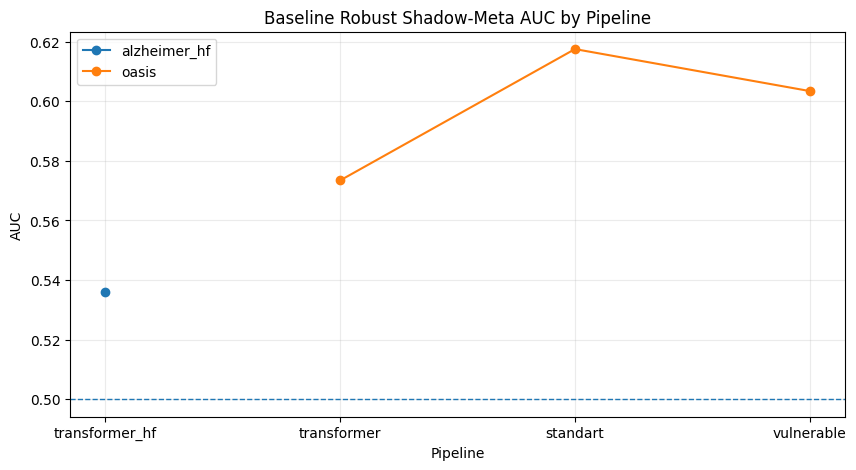

In [4]:
# Global pivot tables
base_pivot = baseline_df.pivot(index='pipeline', columns='dataset', values='robust_shadow_meta_auc')
print('=== Robust AUC baseline by pipeline x dataset ===')
display(base_pivot)

def_pivot = defense_df.pivot_table(
    index=['dataset', 'pipeline'],
    columns='defense',
    values='rob_delta_auc',
    aggfunc='mean',
)
print('=== Robust delta AUC by defense (negative = defense helps) ===')
display(def_pivot)

# Optional quick plot
plt.figure(figsize=(10, 5))
for dataset_name, g in baseline_df.groupby('dataset'):
    plt.plot(g['pipeline'], g['robust_shadow_meta_auc'], marker='o', label=dataset_name)
plt.axhline(0.5, linestyle='--', linewidth=1)
plt.title('Baseline Robust Shadow-Meta AUC by Pipeline')
plt.ylabel('AUC')
plt.xlabel('Pipeline')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## Notes
- Ce notebook lit les sorties sauvegardees dans les notebooks 02-06.
- Si un notebook n'a pas ete execute, les metriques peuvent apparaitre en `NaN`.
- Pour la dataset Alzheimer HF, seules les etapes disponibles dans le dossier sont agregees.